In [39]:
%matplotlib inline

import cv2
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import image as image

def show(I):
    cv2.imshow("image", I)
    key = cv2.waitKey(0)
    cv2.destroyAllWindows()
    cv2.waitKey(1)

In [40]:
icon = cv2.imread("img/icon.jpg")
sample = cv2.imread("img/i-squarelarge.png")

icon = cv2.resize(icon, None, fx=0.5, fy=0.5)
sample = cv2.resize(sample, None, fx=0.5, fy=0.5)

In [41]:
result = cv2.matchTemplate(sample, icon, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

print("Match:", max_val)
print("Location:", max_loc)

h, w = icon.shape[:2]

top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

cv2.rectangle(sample, top_left, bottom_right, (0, 0, 255), 3)

show(sample)

Match: 0.8505834341049194
Location: (511, 149)


In [42]:
#contours test
i_con = cv2.imread("img/i-squarelarge.png")
g = cv2.cvtColor(i_con, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(g, 127, 255, cv2.THRESH_BINARY)

contours,_ = cv2.findContours(binary,
mode=cv2.RETR_EXTERNAL,
method=cv2.CHAIN_APPROX_NONE)

ctrs = cv2.drawContours(i_con, contours, contourIdx=-1,
color=(0,0,255), thickness=3)

show(ctrs)

(160, 125, 3)
0 236
Query keypoints: 104
Train keypoints: 1252
Matches: 104
[97.9795913696289, 114.7606201171875, 136.31947326660156, 144.63401794433594, 160.15304565429688, 162.31143188476562, 167.2901611328125, 169.0561981201172, 169.12716674804688, 173.84475708007812]


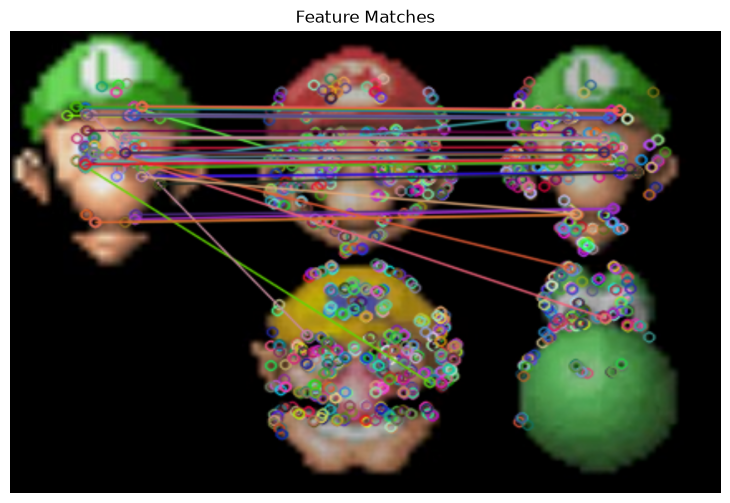

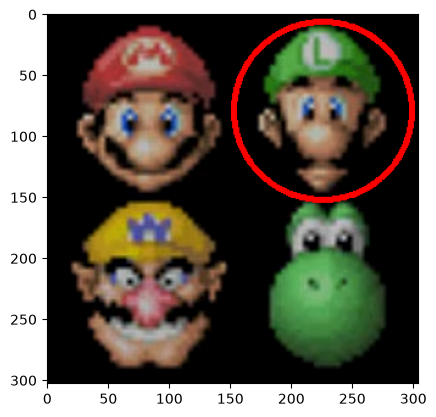

In [43]:
# ORB test
icon = cv2.imread("img/icon.jpg")
sample = cv2.imread("img/i-squaresmall.png")

icon_bw = cv2.cvtColor(icon, cv2.COLOR_BGR2GRAY)
sample_bw = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(nfeatures=15000)

queryKeypoints, queryDescriptors = orb.detectAndCompute(icon_bw, None)
trainKeypoints, trainDescriptors = orb.detectAndCompute(sample_bw, None)

matcher = cv2.BFMatcher()
matches = matcher.match(queryDescriptors, trainDescriptors)
matches = sorted(matches, key=lambda x: x.distance)

best_matches = matches[:50]

final_img = cv2.drawMatches(
    icon, queryKeypoints,
    sample, trainKeypoints,
    best_matches,
    None
)

final_img = cv2.resize(final_img, (1000, 650))

print(icon.shape)
print(icon_bw.min(), icon_bw.max())
print("Query keypoints:", len(queryKeypoints))
print("Train keypoints:", len(trainKeypoints))
print("Matches:", len(matches))

print([m.distance for m in matches[:10]])

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title("Feature Matches")
plt.axis('off')
plt.show()

src_pts = np.float32([
    queryKeypoints[m.queryIdx].pt for m in best_matches
]).reshape(-1, 1, 2)

dst_pts = np.float32([
    trainKeypoints[m.trainIdx].pt for m in best_matches
]).reshape(-1, 1, 2)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

h, w = icon.shape[:2]

corners = np.float32([
    [0, 0],
    [w, 0],
    [w, h],
    [0, h]
]).reshape(-1, 1, 2)

transformed_corners = cv2.perspectiveTransform(corners, H)

result = sample.copy()

pts = transformed_corners.reshape(-1, 2)

cx, cy = pts.mean(axis=0)

sides = [np.linalg.norm(pts[i] - pts[(i + 1) % 4]) for i in range(4)]
r = np.mean(sides) / 2

result = sample.copy()
padding = 1.15
r = np.mean(sides) / 2 * padding
cv2.circle(result, (int(cx), int(cy)), int(r), (0, 0, 255), 3)


plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()